### Task: Demonstrate the effects of lifetime and collisional broadening
1. Discuss what these are
2. Create ideal golden rule spectrum of molecule
3. Model with lifetime broadening
4. Model with increasing pressure broadening

### 1. Logic
In a simpler world, if you measured the spectrum of a single isolated molecule, the peaks would be infinitely sharp. The absorbed and emitted wavelengths would correspond exactly to internal transitions. However. That is not where we live.

Lifetime broadening is due, simply put, to the wobblyness of changing wavefunctions. If the excited state was a permanent, stable change (had an infinite lifetime) then it would have an exact, defined energy level and corresponding spectroscopic wavelength. However, the ability of excited states to spontaneously relax means that they do not have to be stable over that infinite lifetime. The shorter the lifetime of an excited state, the less stable its wavefunction can be, giving many more options for possible energies, and therefore broadening the spectroscopic peak.

Collisional broadening is caused by the interaction with light happening locally in space and time to a collision with another molecule. The collision perturbs the wavefunction in a way that allows its energy to vary. The more likely a collision is, the more likely it is to occur at such as time as to have a large effect on the light interaction. Ergo, the higher the pressure, the more the peak broadening. 

### 2. Applying Fermat's Golden Rule by reusing code
aka never code a date function
~~aka i started this too late to do something more interesting~~

In [1]:
# This library contains utility functions for this course.
#!pip uninstall qcedu-tools
!pip install git+https://github.com/QC-Edu/QChem-utils.git
!pip install git+https://github.com/theochem/grid.git

  Cloning https://github.com/QC-Edu/QChem-utils.git to /tmp/pip-req-build-ymricks3
  Running command git clone --filter=blob:none --quiet https://github.com/QC-Edu/QChem-utils.git /tmp/pip-req-build-ymricks3
  Resolved https://github.com/QC-Edu/QChem-utils.git to commit 008bc97eef519a8005aef2724326d2f242076675
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/theochem/grid.git to /tmp/pip-req-build-3pw9_n2t
  Running command git clone --filter=blob:none --quiet https://github.com/theochem/grid.git /tmp/pip-req-build-3pw9_n2t
  Resolved https://github.com/theochem/grid.git to commit 0b68e7c367c4f844c8d177ee86174ce7dbf6eaf7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from scipy.constants import hbar, c, e, alpha, physical_constants

# This gives you access to the hydrogenic wavefunctions and energies.
from qctools.hydrogen import hydrogenic_wavefunction
from qctools.hydrogen import calc_energy

# This imports the utilities we need to evaluate functions on a grid.
from grid.becke import BeckeWeights
from grid.onedgrid import GaussChebyshev
from grid.rtransform import BeckeRTransform
from grid import AtomGrid

In [3]:
#generating vectorspace for atomic grid
a0 = physical_constants["Bohr radius"][0]

# Now we make an atomic grid. It is a tensor product of an angular grid and a radial grid.
# This the radial grid, with 100 points:
oned = GaussChebyshev(100)
rgrid = BeckeRTransform(1e-4, 1.5).transform_1d_grid(oned)
# Take the tensor product of a radial grid and a (Lebedev-Laikov) angular grid to form an atomic grid.

# The n-pole transition moment between orbitals with orbital angular momentum l_i and l_f will be evaluate exactly as long as
# l_max >= n + l_i + l_f.
l_max = 11
grid = AtomGrid(rgrid, degrees=[l_max])

In [4]:
def spherical_from_cartesian(xyz_points):
    """
    Convert an array of points in Cartesian coordinates to an array in spherical coordinates.

    Parameters
    ----------
    xyz_points : np.ndarray (n_points,3)
        An array of points in Cartesian coordinates.

    Returns
    -------
    np.ndarray (n_points,3)
        An array of points in spherical coordinates.

    """
    x, y, z = xyz_points.transpose()
    ### START YOUR CODE HERE
    #convert cartesian to spherical
    r = np.sqrt(x**2+y**2+z**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y,x)
    #test by going back and forth
    
    ### END YOUR CODE HERE

    return np.array([r, theta, phi]).transpose()


def cartesian_from_spherical(sph_points):
    """
    Convert an array of points in spherical coordinates to an array in Cartesian coordinates.

    Parameters
    ----------
    sph_points : np.ndarray (n_points,3)
        An array of points in spherical coordinates.

    Returns
    -------
    np.ndarray (n_points,3)
        An array of points in Cartesian coordinates.

    """
    r, theta, phi = sph_points.transpose()
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z]).transpose()

In [5]:
#selection rules
def check_orbital_overlap(n_i, l_i, m_i, n_f, l_f, m_f):
    """
    Check if orbitals are orthogonal.
    """
    if not (isinstance(n_i, int) and n_i > 0):
        raise ValueError("Initial state's principle quantum number should be a positive integer.")
    if not (isinstance(n_f, int) and n_f > 0):
        raise ValueError("Final state's principle quantum number should be a positive integer.")
    if not (isinstance(l_i, int) and l_i >= 0 and l_i < n_i):
        raise ValueError(
            "Initial state's orbital angular momentum should be a nonnegative integer and less than the principle quantum number."
        )
    if not (isinstance(l_f, int) and l_f >= 0 and l_f < n_f):
        raise ValueError(
            "Final state's orbital angular momentum should be a nonnegative integer and less than the principle quantum number."
        )
    if not (isinstance(m_i, int) and m_i >= -l_i and m_i <= l_i):
        raise ValueError(
            "Initial state's magnetic quantum number should be an integer between -l_i and l_i."
        )
    if not (isinstance(m_f, int) and m_f >= -l_f and m_f <= l_f):
        raise ValueError(
            "Final state's magnetic quantum number should be an integer between -l_f and l_f."
        )

    # To evaluate a function on the grid, we need to know the grid points in spherical coordinates,
    sph_points = spherical_from_cartesian(grid.points)
    r, theta, phi = sph_points.transpose()
    integrand = (
        hydrogenic_wavefunction(r, theta, phi, n_i, l_i, m_i, Z=1)
        * hydrogenic_wavefunction(r, theta, phi, n_f, l_f, m_f, Z=1).conj()
    )
    overlap = grid.integrate(integrand)

    return overlap


def calc_transition_dipole_sq(n_i, l_i, m_i, n_f, l_f, m_f):
    """
    Calculate the squared-magnitude of the transition dipole moment between an initial hydrogen orbital with
    quantum numbers n_i, m_i, l_i and a final hydrogen orbital with quantum numbers
    n_f, m_f, l_f.

    Parameters
    ----------
    l_i : int
        The initial orbital angular momentum.
    l_f : int
        The final orbital angular momentum.
    m_i : int
        The initial magnetic quantum number.
    m_f : int
        The final magnetic quantum number.
    n_i : int
        The initial principal quantum number.
    n_f : int
        The final principal quantum number.

    Returns
    -------
    float : The squared magnitude of the transition dipole moment.
    """
    # Check that the principle quantum number is a positive integer.
    if not (isinstance(n_i, int) and n_i > 0):
        raise ValueError("Initial state's principle quantum number should be a positive integer.")
    if not (isinstance(n_f, int) and n_f > 0):
        raise ValueError("Final state's principle quantum number should be a positive integer.")
    if not (isinstance(l_i, int) and l_i >= 0 and l_i < n_i):
        raise ValueError(
            "Initial state's orbital angular momentum should be a nonnegative integer and less than the principle quantum number."
        )
    if not (isinstance(l_f, int) and l_f >= 0 and l_f < n_f):
        raise ValueError(
            "Final state's orbital angular momentum should be a nonnegative integer and less than the principle quantum number."
        )
    if not (isinstance(m_i, int) and m_i >= -l_i and m_i <= l_i):
        raise ValueError(
            "Initial state's magnetic quantum number should be an integer between -l_i and l_i."
        )
    if not (isinstance(m_f, int) and m_f >= -l_f and m_f <= l_f):
        raise ValueError(
            "Final state's magnetic quantum number should be an integer between -l_f and l_f."
        )

    # To evaluate a function on the grid, we need to know the grid points and the weights.
    sph_points = spherical_from_cartesian(grid.points)
    x, y, z = grid.points.transpose()
    r, theta, phi = sph_points.transpose()

    # Define the integrand.
    ### START YOUR CODE HERE
    integrand_x = hydrogenic_wavefunction(r,theta,phi,n_i,l_i,m_i,Z=1)*hydrogenic_wavefunction(r,theta,phi,n_f,l_f,m_f,Z=1)*x
    integrand_y = hydrogenic_wavefunction(r,theta,phi,n_i,l_i,m_i,Z=1)*hydrogenic_wavefunction(r,theta,phi,n_f,l_f,m_f,Z=1)*y
    integrand_z = hydrogenic_wavefunction(r,theta,phi,n_i,l_i,m_i,Z=1)*hydrogenic_wavefunction(r,theta,phi,n_f,l_f,m_f,Z=1)*z

    # Integrate the integrand.
    magnitude = (np.abs(grid.integrate(integrand_x))**2+np.abs(grid.integrate(integrand_y))**2
                 +np.abs(grid.integrate(integrand_z))**2
        
    )
    ### END YOUR CODE HERE
    return magnitude

In [6]:
#rate and energy of exact transition
def calc_rate_dipole(trans_energy, trans_dipole_sq):
    """
    Compute the rate of a dipole-allowed transition given the transition energy
    and transition dipole in SI units of Joules and meters, respectively.
    trans_energy : float
        The transition energy in Joules. Traditionally this is defined as the difference in energy between the final and initial states,
        so it should be negative. We then multiply it by minus one.
    trans_dipole_sq : float
        The square of the transition dipole in meters.

    Returns
    -------
    float : The rate of the transition in Hz.
    """
    # Check that the transition energy is positive.
    if not (isinstance(trans_energy, float) and trans_energy < 0):
        raise ValueError("Transition energy should be a negative float.")

    ### START YOUR CODE HERE
    #can just use constants straight cuz they were already imported
    wfi=np.abs(trans_energy/hbar)
    rate = 4*alpha/(3*c**2)*wfi**3*trans_dipole_sq
    ### END YOUR CODE HERE

    return rate


def calc_trans_energy(n_i, n_f):
    """
    Calculate the transition energy between an initial hydrogen orbital with
    quantum numbers n_i, m_i, l_i and a final hydrogen orbital with quantum numbers
    n_f, m_f, l_f in SI units (Joules).
    n_i : int
        The initial principal quantum number.
    n_f : int
        The final principal quantum number.

    Returns
    -------
    float : The transition energy in Joules.
    """

    # Check that the principle quantum number is a positive integer.
    if not (isinstance(n_i, int) and n_i > 0):
        raise ValueError("Initial state's principle quantum number should be a positive integer.")
    if not (isinstance(n_f, int) and n_f > 0):
        raise ValueError("Final state's principle quantum number should be a positive integer.")

    # Calculate the energy of the initial and final states in SI units.
    energy_i = calc_energy(n_i, Z=1, units="SI")
    energy_f = calc_energy(n_f, Z=1, units="SI")

    # Calculate the transition energy
    transition_energy = energy_f - energy_i

    return transition_energy

### 3. Adding in Collisional Broadening
We model collisional broadening using the fraction of molecules that have yet to collide at time t - however this is also equivalent to the odds that any particular molecule will not have collided. 

For a molecule to interact at the ideal wavelength, it needs to have not spontaneously decayed, and not colllided. 
P_unaltered=P_uncollided*P_undecayed, ergo P(t)=P(0)*e^-Afit\*e\^-kPt/sqrt(T)
Tau=sqrt(T)/(sqrt(T)Afi-kP), k measured experimentally

In [24]:
def calc_lifetime(temp, calc_rate, kappa, pressure):
    lifetime=np.sqrt(temp)/(np.sqrt(temp)*calc_rate-kappa*pressure)
    return lifetime

In [25]:
#maths intensity over wavelength
def spectral_line(omega_fi, lifetime, wavelength):
    """
    Calculate the spectral line of a transition given
    its lifetime and transition frequency.

    Parameters
    ----------
    omega_fi : float
        The transition frequency in Hz. Assumed to be negative as the convention
        is that the final state is lower in energy than the initial state.
    lifetime : float
        The lifetime of the transition in seconds.
    wavelength : ndarray
        The wavelength of the transition in nanometers.

    Returns: float
        The intensity of the transition at the given wavelength.
    """
    if not (isinstance(omega_fi, float) and omega_fi < 0):
        raise ValueError("Transition frequency should be a negative float.")
    if not (isinstance(lifetime, float) and lifetime > 0):
        raise ValueError("Lifetime should be a positive float.")
    if not (isinstance(wavelength, np.ndarray) and np.all(wavelength >= 0)):
        raise ValueError("Wavelength should be a nonnegative numpy array.")

    # Change convention so that the wavelength will be positive.
    omega_fi = -omega_fi
    # Convert the wavelength to meters.
    wavelength = wavelength * 1.0e-9

    ### START YOUR CODE HERE
    # Convert the wavelength to angular frequency.
    freq= c/wavelength
    omega = freq*2*np.pi

    # Compute the intensity of the transition at the given wavelength.
    intensity = (2*np.pi*lifetime)**(-1)/((2*lifetime)**(-2)+(omega-omega_fi)**2)
    ### END YOUR CODE HERE

    return intensity

In [47]:
#plots intensity over wavelength
def plot_intensity(n_i, n_f,pressure,kappa,temp):
    """
    Plot the spectral line of a transition given
    its initial and final quantum numbers.
    
    Parameters
    ----------
    n_i : int
        The initial principal quantum number.
    n_f : int
        The final principal quantum number.
        
    Returns
    -------
    None
    """
    # Calculate the transition energy
    trans_energy = calc_trans_energy(n_i, n_f)
    # Calculate the wavelength of the transition in nm.
    wavelength_if = -1 * (hbar * 2 * np.pi * c) / trans_energy * 1e9
    # Calculate the transition dipole moment squared.
    trans_dipole_sq = calc_transition_dipole_sq(n_i, 1, 0, n_f, 0, 0) * a0 ** 2
    # Calculate the transition rate.
    calc_rate = calc_rate_dipole(trans_energy, trans_dipole_sq)
    trans_frequency = trans_energy / hbar
    lifetime = calc_lifetime(temp, calc_rate, kappa, pressure)
    wavelength = np.linspace(wavelength_if - 5e-5, wavelength_if + 5e-5, 1000)
    intensity = spectral_line(trans_frequency, lifetime, wavelength)
    plt.plot(wavelength, intensity, label=pressure)
    plt.axvline(wavelength_if, color='r', linestyle='--', label='Transition wavelength')
    plt.legend()
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
   

In [48]:
#def plot_intensity(n_i,n_f,kappa,temp):
 #   wavelength = np.linspace(wavelength_if - 5e-5, wavelength_if + 5e-5, 1000)
    

In [49]:
    #print(trans_frequency, lifetime, wavelength_if)

In [50]:
#plot_spectral_line(2, 1)

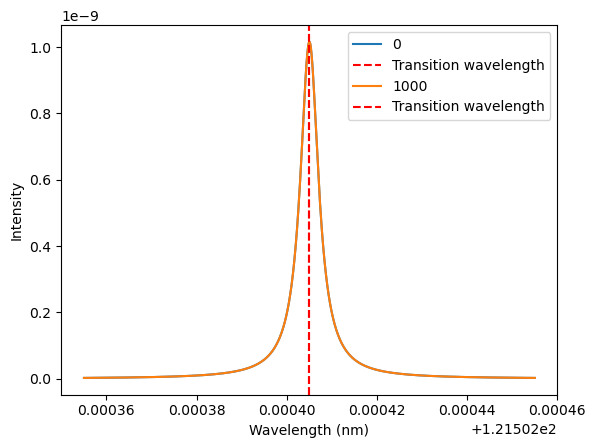

In [51]:
temp=273
#I have no idea what realistic values for kappa are
kappa=1
plot_intensity(2,1,0,kappa,temp)


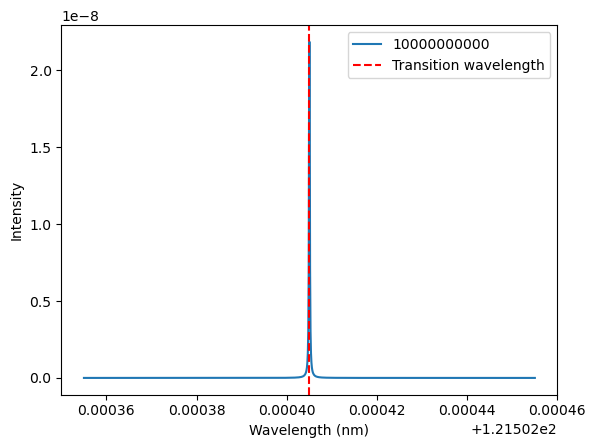

In [53]:
plot_intensity(2,1,10000000000,kappa,temp)